In [18]:
from pathlib import Path
import importlib
import utils

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

importlib.reload(utils)

all_prices = pd.read_csv(
    Path("../01-data/prices.txt"),
    sep=r"\s+",
    header=0,  # extracts tickers from the first line
)

if all_prices.shape[1] != 51:
    raise ValueError(
        f"Expected 51 instrument columns; received {all_prices.shape}"
    )

if not all_prices.columns.is_unique:
    raise ValueError("Ticker names must be unique")

all_prices = all_prices.apply(pd.to_numeric, errors="raise")
all_prices.index.name = "day"

print(all_prices.columns.tolist())
display(all_prices.head())

['ALGO', 'AENO', 'LSST', 'SRNA', 'ELLT', 'AMRP', 'OTCS', 'HETT', 'HUXZ', 'DUCT', 'SMAH', 'NPCK', 'MSDP', 'EORC', 'CUBO', 'HRET', 'ANSO', 'DIHO', 'RTTH', 'SPLZ', 'NWIG', 'MMBT', 'MDGI', 'AGVF', 'RRES', 'CTGI', 'ALUT', 'ACAC', 'SRTX', 'GARI', 'RCRI', 'ACIX', 'CCNS', 'MTNS', 'IHOZ', 'NAYO', 'FWWG', 'EELT', 'HRND', 'AETS', 'ULXY', 'BLBT', 'BENI', 'ITPA', 'HTRK', 'NGTE', 'ILVX', 'FCSG', 'FARS', 'MHRM', 'EAFC']


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
day,,,,,,,,,,,,,,,,,,,,,
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56


In [14]:
# Hold out the final 250 days

TEST_DAYS = 250

if len(all_prices) <= TEST_DAYS:
    raise ValueError("Dataset must contain more than 250 days")

train_prices = all_prices.iloc[:-TEST_DAYS].copy()
test_prices = all_prices.iloc[-TEST_DAYS:].copy()

print(f"Train: {train_prices.index.min()}-{train_prices.index.max()}")
print(f"Test:  {test_prices.index.min()}-{test_prices.index.max()}")
print(f"Shapes: train={train_prices.shape}, test={test_prices.shape}")

prices = train_prices
returns = utils.calculate_returns(prices)
test_returns = utils.calculate_returns(test_prices)

Train: 0-499
Test:  500-749
Shapes: train=(500, 51), test=(250, 51)


In [16]:
# Cell 5: instrument summary statistics

summary = utils.summary_statistics(
    prices,
    input_type="prices",
)

display(summary[[
    "instrument_index",
    "instrument_name",
    "mean",
    "annualized_volatility",
    "sharpe",
]])

,instrument_index,instrument_name,mean,annualized_volatility,sharpe
instrument,,,,,
ALGO,0,ALGO,-0.000227,0.156970,-0.361654
AENO,1,AENO,-0.001087,0.295123,-0.920463
LSST,2,LSST,-0.000320,0.334277,-0.239087
SRNA,3,SRNA,-0.000999,0.248959,-1.003232
ELLT,4,ELLT,0.000615,0.273669,0.561515
AMRP,5,AMRP,-0.000191,0.437335,-0.109393
OTCS,6,OTCS,0.001886,0.422558,1.116039
HETT,7,HETT,0.000009,0.234108,0.009743
HUXZ,8,HUXZ,-0.001022,0.337824,-0.756522


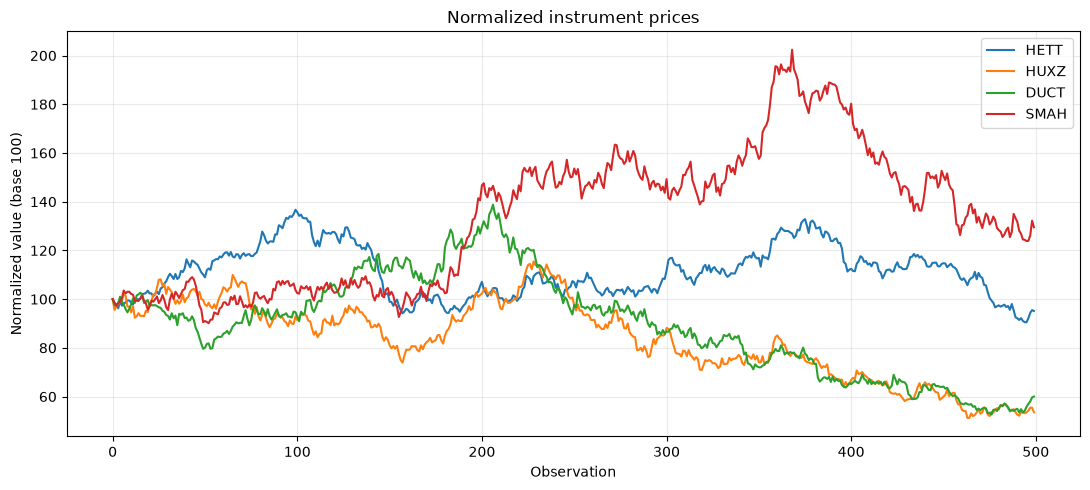

In [22]:
selected_prices = utils.select_instruments(
    prices,
    [7, 8, 9, 10],
)

fig, ax = utils.plot_series(
    selected_prices,
    normalize=True,
    title="Normalized instrument prices",
)

plt.show()